---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 1. Фізичні основи напівпровідників</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Енергетичні зони в кристалі. Метали, напівпровідники, діелектрики</li>
  <li>Власні та домішкові напівпровідники</li>
  <li>Статистика носіїв заряду: функція Фермі–Дірака, рівень Фермі</li>
  <li>Температурна залежність концентрації носіїв</li>
  <li>Дрейф і дифузія, рухливість, питомий опір</li>
  <li>Генерація, рекомбінація, час життя і дифузійна довжина</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 1 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Енергетичні зони в кристалі](#band-origin)
* [Класифікація твердих тіл: метали, напівпровідники, діелектрики](#band-classes)
* [Власний напівпровідник](#intrinsic)
* [Домішкові напівпровідники n- і p-типу](#extrinsic)
* [Статистика носіїв заряду. Рівень Фермі](#statistics)
    * [🔬 Інтерактивно: положення рівня Фермі та розподіл носіїв у зонах](#fermi-interactive)
* [Температурна залежність концентрації носіїв](#n-vs-T)
    * [🔬 Інтерактивно: три області n(T) та ρ(T)](#nT-interactive)
    * [⚙️ PySpice: зворотний струм діода як «термометр» n_i²](#spice-is-T)
* [Рух носіїв: дрейф, дифузія, рухливість](#transport)
* [Генерація та рекомбінація. Час життя і дифузійна довжина](#recombination)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

# Параметри напівпровідників при 300 К (Sze & Ng, 2007)
MATERIALS = {   #  Eg0 (еВ, 0 К), Varshni a (еВ/К), b (К), Nc (см^-3), Nv (см^-3), колір
    'Ge':   dict(Eg0=0.7437, a=4.774e-4, b=235.0, Nc=1.04e19, Nv=6.0e18, color='#7c3aed'),
    'Si':   dict(Eg0=1.1695, a=4.73e-4,  b=636.0, Nc=2.86e19, Nv=2.66e19, color='#2563eb'),
    'GaAs': dict(Eg0=1.519,  a=5.405e-4, b=204.0, Nc=4.7e17,  Nv=9.0e18,  color='#dc2626'),
}
kB_eV = 8.617333e-5   # еВ/К
def Eg_T(m, T):
    """Ширина забороненої зони за формулою Варшні, еВ"""
    p = MATERIALS[m]; return p['Eg0'] - p['a']*T**2/(T + p['b'])
def ni_T(m, T):
    """Власна концентрація n_i(T), см^-3"""
    p = MATERIALS[m]
    Nc = p['Nc']*(T/300)**1.5; Nv = p['Nv']*(T/300)**1.5
    return np.sqrt(Nc*Nv)*np.exp(-Eg_T(m, T)/(2*kB_eV*T))
for m in MATERIALS:
    print(f"{m:5s}: Eg(300 K) = {Eg_T(m, 300):.3f} еВ,  n_i(300 K) = {ni_T(m, 300):.2e} см^-3")

Ge   : Eg(300 K) = 0.663 еВ,  n_i(300 K) = 2.12e+13 см^-3
Si   : Eg(300 K) = 1.124 еВ,  n_i(300 K) = 9.98e+09 см^-3
GaAs : Eg(300 K) = 1.422 еВ,  n_i(300 K) = 2.32e+06 см^-3


---

# Енергетичні зони в кристалі <a class="anchor" id="band-origin"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати походження енергетичних зон з дискретних рівнів ізольованих атомів
> - Розрізняти валентну зону, зону провідності і заборонену зону
> - Класифікувати тверді тіла на метали, напівпровідники й діелектрики за зонною діаграмою
> - Пояснювати механізм власної та домішкової провідності напівпровідників

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Валентна зона** | Верхня з дозволених зон, повністю заповнених електронами при $T = 0$ К; її стеля позначається $E_v$ |
| **Зона провідності** | Найближча вища дозволена зона; при $T=0$ К у напівпровіднику порожня; її дно — $E_c$ |
| **Заборонена зона $E_g$** | Інтервал енергій $E_g = E_c - E_v$, яких електрон в ідеальному кристалі мати не може |
| **Рівень Фермі $E_F$** | Енергія, ймовірність заповнення якої електроном дорівнює 1/2 (у рівновазі — однаковий у всій системі) |
| **Дірка** | Незайнятий електроном стан у валентній зоні; поводиться як рухомий позитивний заряд $+q$ |
| **Донор / акцептор** | Домішковий атом, що віддає електрон у зону провідності / захоплює електрон з валентної зони |

В ізольованому атомі електрони займають **дискретні** енергетичні рівні (1s, 2s, 2p, 3s, 3p, …). Коли $N$ однакових атомів зближуються і утворюють кристал, їхні електронні оболонки перекриваються. За **принципом Паулі** жодні два електрони системи не можуть мати однаковий набір квантових чисел, тому кожен рівень атома розщеплюється на $N$ близько розташованих підрівнів. Оскільки $N \sim 5\cdot10^{22}$ см⁻³, відстань між підрівнями мізерна, і вони утворюють практично неперервну **дозволену енергетичну зону**.

Для кремнію (конфігурація зовнішньої оболонки $3s^2 3p^2$) картина така: при великій відстані між атомами є рівень $3s$ ($2N$ станів, $2N$ електронів) і рівень $3p$ ($6N$ станів, лише $2N$ електронів). При зближенні атомів зони $3s$ і $3p$ розширюються, перекриваються, а потім, за рівноважної відстані $a_0$, знову розходяться на дві зони по $4N$ станів (це наслідок $sp^3$-гібридизації — тетраедричних ковалентних зв'язків). Нижня зона — **валентна** — повністю заповнена всіма $4N$ валентними електронами, верхня — **зона провідності** — при $T = 0$ К порожня. Між ними лежить **заборонена зона** шириною $E_g$.

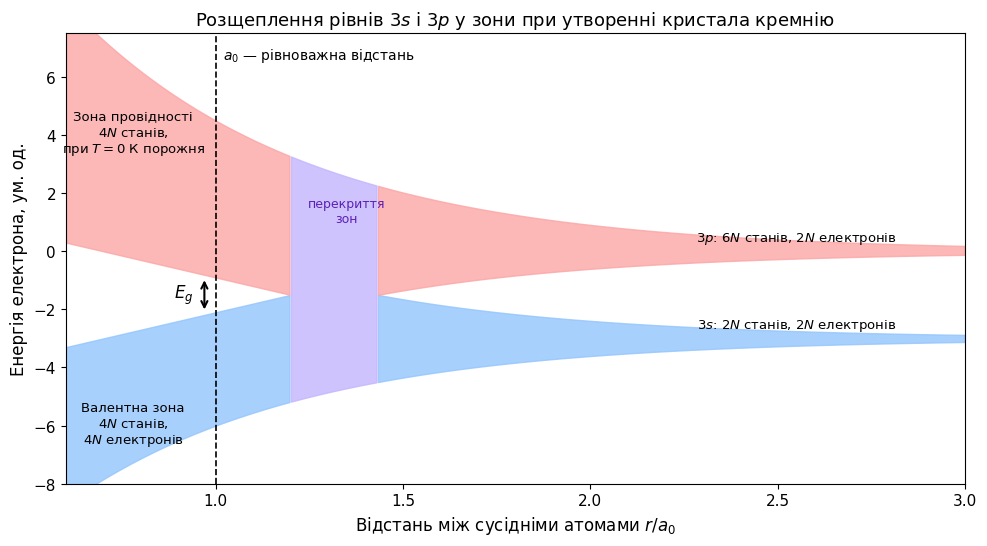

In [2]:
# Утворення зон з рівнів 3s і 3p при зближенні атомів кремнію (якісна схема, умовні одиниці енергії)
r = np.linspace(0.6, 3.0, 600)                  # відстань між атомами r / a0
E_s, E_p = -3.0, 0.0                             # рівні ізольованого атома
w = 3.0*np.exp(-1.6*(r - 1.0))                   # напівширина зони, що зростає при зближенні
r_m = 1.0 + np.log(2)/1.6                        # тут зони 3s і 3p починають перекриватися
r_x, a0, Eg_a0 = 1.2, 1.0, 1.2                   # нижче r_x зони знову розходяться (sp3-гібридизація)
mid = (E_s + E_p)/2

fig, ax = plt.subplots(figsize=(10, 5.6))
sep = r >= r_m                                    # окремі зони 3s і 3p
ax.fill_between(r[sep], (E_s - w)[sep], (E_s + w)[sep], color='#93c5fd', alpha=0.8)
ax.fill_between(r[sep], (E_p - w)[sep], (E_p + 1.5*w)[sep], color='#fca5a5', alpha=0.8)
mrg = (r >= r_x) & (r <= r_m)                     # спільна (перекрита) зона
ax.fill_between(r[mrg], (E_s - w)[mrg], (E_p + 1.5*w)[mrg], color='#c4b5fd', alpha=0.8)
spl = r <= r_x                                    # валентна зона і зона провідності
gap = Eg_a0*(r_x - r[spl])/(r_x - a0)
ax.fill_between(r[spl], (E_s - w)[spl], mid - gap/2, color='#93c5fd', alpha=0.8)
ax.fill_between(r[spl], mid + gap/2, (E_p + 1.5*w)[spl], color='#fca5a5', alpha=0.8)

ax.axvline(a0, color='k', ls='--', lw=1.2)
ax.text(a0 + 0.02, 6.6, r'$a_0$ — рівноважна відстань', fontsize=10)
ax.annotate('', xy=(a0 - 0.03, mid + Eg_a0/2), xytext=(a0 - 0.03, mid - Eg_a0/2),
            arrowprops=dict(arrowstyle='<->', lw=1.5))
ax.text(a0 - 0.06, mid, '$E_g$', ha='right', va='center', fontsize=12)
ax.text(0.78, 3.4, 'Зона провідності\n$4N$ станів,\nпри $T=0$ К порожня', ha='center', fontsize=9.5)
ax.text(0.78, -6.6, 'Валентна зона\n$4N$ станів,\n$4N$ електронів', ha='center', fontsize=9.5)
ax.text(2.55, E_p + 0.35, '$3p$: $6N$ станів, $2N$ електронів', ha='center', fontsize=9.5)
ax.text(2.55, E_s + 0.35, '$3s$: $2N$ станів, $2N$ електронів', ha='center', fontsize=9.5)
ax.text(1.35, 1.0, 'перекриття\nзон', ha='center', fontsize=9, color='#5b21b6')
ax.set_xlim(0.6, 3.0); ax.set_ylim(-8, 7.5)
ax.set_xlabel('Відстань між сусідніми атомами $r/a_0$')
ax.set_ylabel('Енергія електрона, ум. од.')
ax.set_title('Розщеплення рівнів $3s$ і $3p$ у зони при утворенні кристала кремнію')
ax.grid(False)
plt.tight_layout(); plt.show()

# Класифікація твердих тіл: метали, напівпровідники, діелектрики <a class="anchor" id="band-classes"></a>

Електропровідність визначається тим, чи є **поруч із найвищими заповненими станами вільні стани**, на які електрон може перейти, отримавши від зовнішнього поля малу енергію.

- **Метали.** Верхня зона, що містить електрони, заповнена лише частково (або валентна зона перекривається із зоною провідності). Вільні стани є безпосередньо над рівнем Фермі, тому навіть мале поле прискорює електрони: $\sigma \sim 10^6$–$10^8$ См/м. З ростом температури провідність **зменшується** — зростає розсіювання електронів на теплових коливаннях ґратки (фононах).
- **Напівпровідники.** Заборонена зона помірна ($E_g \approx 0{,}1$–$3{,}5$ еВ). При $T > 0$ частина електронів завдяки тепловій енергії долає $E_g$, з'являються вільні електрони в зоні провідності й дірки у валентній. Кількість носіїв, а отже провідність, **зростає** з температурою приблизно як $\exp(-E_g/2kT)$.
- **Діелектрики.** Заборонена зона широка ($E_g \gtrsim 4$ еВ). Теплова енергія $kT \approx 0{,}026$ еВ при 300 К на два порядки менша, тож провідність нехтовно мала.

| Матеріал | Ge | Si | GaAs | GaP | 4H-SiC | GaN | Алмаз | SiO₂ |
|---|---|---|---|---|---|---|---|---|
| $E_g$ при 300 К, еВ | 0,66 | 1,12 | 1,42 | 2,26 | 3,26 | 3,4 | 5,47 | ≈ 9 |

Межа між напівпровідниками й діелектриками умовна: широкозонні SiC, GaN, алмаз — це вже «напівпровідники для силової та високотемпературної електроніки».

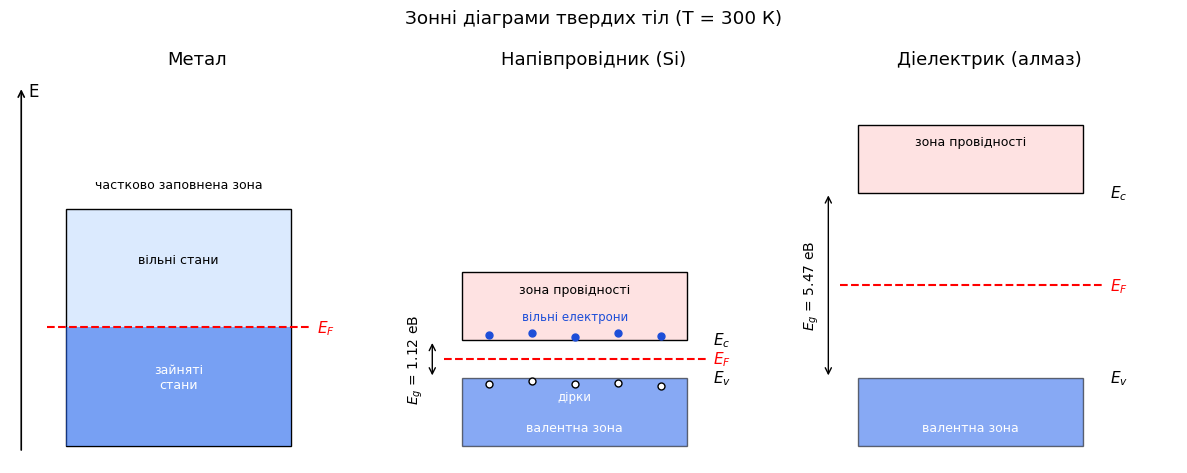

In [3]:
# Зонні діаграми при 300 К (масштаб енергії — реальний, еВ)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharey=True)
rng = np.random.default_rng(1)
cases = [('Метал', None), ('Напівпровідник (Si)', 1.12), ('Діелектрик (алмаз)', 5.47)]
for ax, (name, Eg) in zip(axes, cases):
    ax.set_xlim(0, 1); ax.set_ylim(-2.5, 9.0); ax.axis('off'); ax.set_title(name)
    if Eg is None:
        ax.add_patch(patches.Rectangle((0.15, -2.0), 0.6, 7.0, fc='#dbeafe', ec='k'))       # зона
        ax.add_patch(patches.Rectangle((0.15, -2.0), 0.6, 3.5, fc='#2563eb', ec='none', alpha=0.55))  # зайняті стани
        ax.plot([0.1, 0.8], [1.5, 1.5], 'r--', lw=1.5); ax.text(0.82, 1.5, '$E_F$', color='r', va='center')
        ax.text(0.45, 3.4, 'вільні стани', ha='center', fontsize=9)
        ax.text(0.45, -0.3, 'зайняті\nстани', ha='center', fontsize=9, color='white')
        ax.text(0.45, 5.6, 'частково заповнена зона', ha='center', fontsize=9)
        continue
    Ev, Ec = 0.0, Eg
    ax.add_patch(patches.Rectangle((0.15, Ev - 2.0), 0.6, 2.0, fc='#2563eb', ec='k', alpha=0.55))
    ax.add_patch(patches.Rectangle((0.15, Ec), 0.6, 2.0, fc='#fee2e2', ec='k'))
    ax.text(0.45, Ev - 1.45, 'валентна зона', ha='center', va='center', color='white', fontsize=9)
    ax.text(0.45, Ec + 1.5, 'зона провідності', ha='center', va='center', fontsize=9)
    ax.plot([0.1, 0.8], [Eg/2, Eg/2], 'r--', lw=1.5); ax.text(0.82, Eg/2, '$E_F$', color='r', va='center')
    ax.annotate('', xy=(0.07, Ec), xytext=(0.07, Ev), arrowprops=dict(arrowstyle='<->'))
    ax.text(0.05, Eg/2, f'$E_g$ = {Eg} еВ', rotation=90, ha='right', va='center', fontsize=10)
    ax.text(0.82, Ec, '$E_c$', va='center'); ax.text(0.82, Ev, '$E_v$', va='center')
    if Eg < 2:   # кілька теплових електронів біля дна зони провідності і дірок біля стелі валентної
        xs = np.linspace(0.22, 0.68, 5)
        ax.plot(xs, Ec + 0.15 + 0.08*rng.uniform(-1, 1, 5), 'o', color='#1d4ed8', ms=5)
        ax.plot(xs, Ev - 0.15 + 0.08*rng.uniform(-1, 1, 5), 'o', mfc='white', mec='k', ms=5)
        ax.text(0.45, Ec + 0.6, 'вільні електрони', ha='center', fontsize=8.5, color='#1d4ed8')
        ax.text(0.45, Ev - 0.65, 'дірки', ha='center', fontsize=8.5, color='white')
axes[0].annotate('', xy=(0.03, 8.6), xytext=(0.03, -2.2), arrowprops=dict(arrowstyle='->', lw=1.2))
axes[0].text(0.05, 8.3, 'E', fontsize=12)
plt.suptitle('Зонні діаграми твердих тіл (T = 300 К)', y=0.98)
plt.tight_layout(); plt.show()

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перший напівпровідниковий прилад — точковий детектор **Брауна** (1874): металева голка, притиснута до кристала сульфіду свинцю, випрямляла струм. Пояснити цей ефект змогли лише через пів століття, коли **Блох**, **Зоммерфельд** і **Вільсон** (1928–1931) побудували квантову зонну теорію твердого тіла. Саме А. Вільсон 1931 р. уперше пояснив відмінність металів, напівпровідників і діелектриків через заповнення зон.

</div>

---

# Власний напівпровідник <a class="anchor" id="intrinsic"></a>

**Власним** називають хімічно чистий, бездефектний напівпровідник. У кристалі кремнію кожен атом (IV група) утворює чотири **ковалентні зв'язки** з сусідами; кожен зв'язок — це пара електронів зі спільною орбіталлю. При $T = 0$ К всі електрони задіяні у зв'язках, вільних носіїв немає.

При $T > 0$ теплові коливання ґратки час від часу розривають зв'язок: електрон стає вільним (переходить у зону провідності), а на місці розірваного зв'язку лишається **дірка** — незаповнений стан, який може зайняти електрон сусіднього зв'язку. Так дірка «переміщується» кристалом як позитивний заряд $+q$. Процес утворення пари називають **тепловою генерацією**, зворотний процес — **рекомбінацією**. У рівновазі швидкості генерації і рекомбінації рівні, а концентрації електронів і дірок однакові:

$$n = p = n_i, \qquad n_i(T) = \sqrt{N_c N_v}\;\exp\!\left(-\frac{E_g}{2kT}\right), \qquad N_{c,v} \propto T^{3/2},$$

де $N_c$, $N_v$ — **ефективні густини станів** у зоні провідності й валентній зоні. Для Si при 300 К $n_i \approx 1\cdot10^{10}$ см⁻³ (сучасне значення $9{,}65\cdot10^{9}$; у старших підручниках — $1{,}5\cdot10^{10}$), тобто лише один атом з $5\cdot10^{12}$ «віддає» електрон. Рівень Фермі власного напівпровідника $E_i$ лежить майже посередині забороненої зони (зміщення $\tfrac{kT}{2}\ln(N_v/N_c)$ для Si менше 1 меВ).

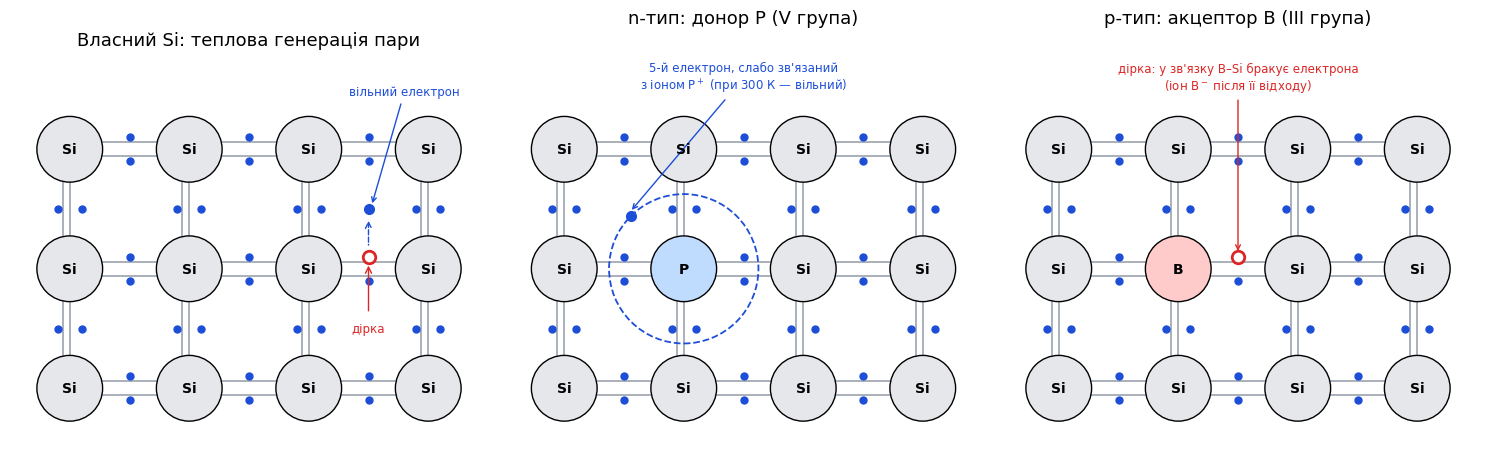

In [4]:
# Площинна модель ґратки кремнію: власний, n-тип (донор P), p-тип (акцептор B)
def lattice(ax, center_label='Si', mode='intrinsic'):
    step = 2.0
    pts = [(i*step, j*step) for i in range(4) for j in range(3)]
    cx, cy = 1*step, 1*step                               # центральний (домішковий) атом
    for (x, y) in pts:                                   # зв'язки — по два електрони
        for dx, dy in [(step, 0), (0, step)]:
            if (x + dx, y + dy) in pts:
                ax.plot([x, x + dx], [y + 0.12*(dy == 0), y + dy + 0.12*(dy == 0)], color='#9ca3af', lw=1.2)
                ax.plot([x - 0.12*(dx == 0), x + dx - 0.12*(dx == 0)], [y - 0.12*(dy == 0), y + dy - 0.12*(dy == 0)], color='#9ca3af', lw=1.2)
                broken = (mode == 'intrinsic' and (x, y) == (2*step, 1*step) and dx == step)
                missing = (mode == 'p' and (x, y) == (cx, cy) and dx == step)
                ex, ey = x + dx/2, y + dy/2
                if dx:   # горизонтальний зв'язок: електрони зверху і знизу
                    e_pos = [(ex, ey + 0.2), (ex, ey - 0.2)]
                else:
                    e_pos = [(ex - 0.2, ey), (ex + 0.2, ey)]
                for k, (px, py) in enumerate(e_pos):
                    if (broken or missing) and k == 0:
                        ax.plot(px, py, 'o', mfc='white', mec='#dc2626', ms=9, mew=2)       # дірка
                        continue
                    ax.plot(px, py, 'o', color='#1d4ed8', ms=5)
    for (x, y) in pts:
        lab, fc = 'Si', '#e5e7eb'
        if (x, y) == (cx, cy) and mode == 'n': lab, fc = 'P', '#bfdbfe'
        if (x, y) == (cx, cy) and mode == 'p': lab, fc = 'B', '#fecaca'
        ax.add_patch(plt.Circle((x, y), 0.55, fc=fc, ec='k', zorder=3))
        ax.text(x, y, lab, ha='center', va='center', fontsize=10, zorder=4, fontweight='bold')
    if mode == 'intrinsic':
        ax.plot(5.0, 3.0, 'o', color='#1d4ed8', ms=7, zorder=6)                 # вільний електрон — між атомами
        ax.annotate('', xy=(5.0, 2.35), xytext=(5.0, 2.85), arrowprops=dict(arrowstyle='<-', color='#1d4ed8', ls='--'))
        ax.annotate('вільний електрон', xy=(5.05, 3.05), xytext=(5.6, 4.9), fontsize=8.5, color='#1d4ed8',
                    ha='center', arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1))
        ax.text(5.0, 1.0, 'дірка', fontsize=8.5, color='#dc2626', ha='center', va='center')
        ax.annotate('', xy=(5.0, 2.1), xytext=(5.0, 1.25), arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1))
        ax.set_title('Власний Si: теплова генерація пари')
    if mode == 'n':
        ax.add_patch(plt.Circle((cx, cy), 1.25, fill=False, ls='--', ec='#1d4ed8', lw=1.3, zorder=5))
        ax.plot(cx - 0.88, cy + 0.88, 'o', color='#1d4ed8', ms=7, zorder=6)
        ax.annotate('5-й електрон, слабо зв\'язаний\nз іоном P$^+$ (при 300 К — вільний)', xy=(cx - 0.9, cy + 0.95),
                    xytext=(3.0, 5.0), fontsize=8.5, color='#1d4ed8', ha='center',
                    arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1))
        ax.set_title('n-тип: донор P (V група)', pad=22)
    if mode == 'p':
        ax.annotate('дірка: у зв\'язку B–Si бракує електрона\n(іон B$^-$ після її відходу)', xy=(cx + 1.0, cy + 0.25),
                    xytext=(3.0, 5.0), fontsize=8.5, color='#dc2626', ha='center',
                    arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1))
        ax.set_title('p-тип: акцептор B (III група)', pad=22)
    ax.set_xlim(-1, 7); ax.set_ylim(-1.1, 5.6); ax.set_aspect('equal'); ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, mode in zip(axes, ['intrinsic', 'n', 'p']):
    lattice(ax, mode=mode)
plt.tight_layout(); plt.show()

---

# Домішкові напівпровідники n- і p-типу <a class="anchor" id="extrinsic"></a>

**Легування** — контрольоване введення домішок — змінює концентрацію носіїв одного знаку на багато порядків.

**Донори (n-тип).** Атом V групи (P, As, Sb) заміщає атом Si; чотири з п'яти його валентних електронів утворюють зв'язки, а п'ятий слабо утримується кулонівським полем іона. Енергія іонізації мала: для P у Si $E_c - E_d = 0{,}045$ еВ (As — 0,054; Sb — 0,039 еВ), тому вже при кімнатній температурі практично всі донори іонізовані. Отже $n_0 \approx N_d$; **основні носії — електрони**, неосновні — дірки.

**Акцептори (p-тип).** Атом III групи (B, Al, Ga, In) має на один валентний електрон менше; він захоплює електрон із сусіднього зв'язку, утворюючи нерухомий від'ємний іон і рухому **дірку**. Для B у Si $E_a - E_v = 0{,}045$ еВ. Тоді $p_0 \approx N_a$; основні носії — дірки.

Для будь-якого (невиродженого) напівпровідника в рівновазі виконується **закон діючих мас**:

$$n_0\,p_0 = n_i^2 \quad\Rightarrow\quad \text{n-тип: } p_0 = \frac{n_i^2}{N_d}, \qquad \text{p-тип: } n_0 = \frac{n_i^2}{N_a}.$$

Наприклад, у кремнії з $N_d = 10^{16}$ см⁻³ маємо $n_0 = 10^{16}$ і $p_0 \approx 10^{4}$ см⁻³ — електронів у $10^{12}$ разів більше, ніж дірок. Рівень Фермі зміщується до зони основних носіїв:

$$E_c - E_F = kT\ln\frac{N_c}{N_d}, \qquad E_F - E_v = kT\ln\frac{N_v}{N_a}.$$

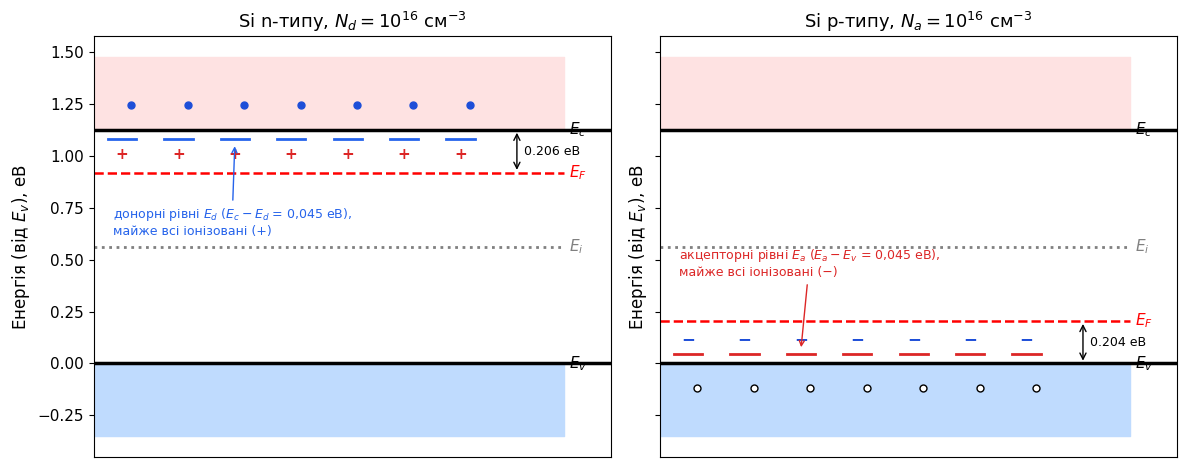

n-тип: Ec - EF = 0.206 еВ,  EF - Ei = 0.357 еВ;   p-тип: EF - Ev = 0.204 еВ,  Ei - EF = 0.357 еВ


In [5]:
# Зонні діаграми Si n- і p-типу в масштабі (T = 300 K, N = 1e16 см^-3)
T = 300.0; kT = kB_eV*T; Eg = Eg_T('Si', T); Nc, Nv = MATERIALS['Si']['Nc'], MATERIALS['Si']['Nv']
N = 1e16
EF_n = Eg - kT*np.log(Nc/N)          # відлік від Ev = 0
EF_p = kT*np.log(Nv/N)
Ei = Eg/2 + kT/2*np.log(Nv/Nc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, typ in zip(axes, ['n', 'p']):
    ax.axhline(Eg, color='k', lw=2.5); ax.axhline(0, color='k', lw=2.5)
    ax.fill_between([0, 10], Eg, Eg + 0.35, color='#fee2e2'); ax.fill_between([0, 10], -0.35, 0, color='#bfdbfe')
    ax.plot([0, 10], [Ei, Ei], ':', color='gray'); ax.text(10.1, Ei, '$E_i$', va='center', color='gray')
    ax.text(10.1, Eg, '$E_c$', va='center'); ax.text(10.1, 0, '$E_v$', va='center')
    if typ == 'n':
        Ed = Eg - 0.045
        for x in np.arange(0.6, 7.9, 1.2):
            ax.plot([x - 0.3, x + 0.3], [Ed, Ed], color='#2563eb', lw=2)
            ax.text(x, Ed - 0.075, '+', ha='center', va='center', color='#dc2626', fontsize=11, fontweight='bold')
            ax.plot(x + 0.2, Eg + 0.12, 'o', color='#1d4ed8', ms=5)
        ax.plot([0, 10], [EF_n, EF_n], 'r--', lw=1.8); ax.text(10.1, EF_n, '$E_F$', color='r', va='center')
        ax.annotate('донорні рівні $E_d$ ($E_c-E_d$ = 0,045 еВ),\nмайже всі іонізовані (+)', xy=(3.0, Ed - 0.02),
                    xytext=(0.4, 0.62), fontsize=9, color='#2563eb', arrowprops=dict(arrowstyle='->', color='#2563eb'))
        ax.annotate('', xy=(9.0, Eg), xytext=(9.0, EF_n), arrowprops=dict(arrowstyle='<->'))
        ax.text(9.15, (Eg + EF_n)/2, f'{Eg-EF_n:.3f} еВ', va='center', fontsize=9)
        ax.set_title('Si n-типу, $N_d = 10^{16}$ см$^{-3}$')
    else:
        Ea = 0.045
        for x in np.arange(0.6, 7.9, 1.2):
            ax.plot([x - 0.3, x + 0.3], [Ea, Ea], color='#dc2626', lw=2)
            ax.text(x, Ea + 0.075, '−', ha='center', va='center', color='#1d4ed8', fontsize=12, fontweight='bold')
            ax.plot(x + 0.2, -0.12, 'o', mfc='white', mec='k', ms=5)
        ax.plot([0, 10], [EF_p, EF_p], 'r--', lw=1.8); ax.text(10.1, EF_p, '$E_F$', color='r', va='center')
        ax.annotate('акцепторні рівні $E_a$ ($E_a-E_v$ = 0,045 еВ),\nмайже всі іонізовані (−)', xy=(3.0, Ea + 0.02),
                    xytext=(0.4, 0.42), fontsize=9, color='#dc2626', arrowprops=dict(arrowstyle='->', color='#dc2626'))
        ax.annotate('', xy=(9.0, 0), xytext=(9.0, EF_p), arrowprops=dict(arrowstyle='<->'))
        ax.text(9.15, EF_p/2, f'{EF_p:.3f} еВ', va='center', fontsize=9)
        ax.set_title('Si p-типу, $N_a = 10^{16}$ см$^{-3}$')
    ax.set_xlim(0, 11); ax.set_ylim(-0.45, Eg + 0.45); ax.set_xticks([])
    ax.set_ylabel('Енергія (від $E_v$), еВ'); ax.grid(False)
plt.tight_layout(); plt.show()
print(f'n-тип: Ec - EF = {Eg-EF_n:.3f} еВ,  EF - Ei = {EF_n-Ei:.3f} еВ;   p-тип: EF - Ev = {EF_p:.3f} еВ,  Ei - EF = {Ei-EF_p:.3f} еВ')

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

«Напівпровідник n-типу заряджений негативно, бо в ньому багато електронів» — **хибне** твердження. Кожен електрон провідності залишив позаду позитивний іон донора, тому легований кристал **електрично нейтральний**: $n_0 + N_a^- = p_0 + N_d^+$. Нескомпенсований об'ємний заряд з'являється лише там, де рухомі носії пішли, а нерухомі іони залишились, — наприклад, біля p-n переходу (Лекція 2).

</div>

---

# Статистика носіїв заряду. Рівень Фермі <a class="anchor" id="statistics"></a>

Ймовірність того, що стан з енергією $E$ зайнятий електроном, у рівновазі описує **функція Фермі–Дірака**:

$$f(E) = \frac{1}{1 + \exp\!\left(\dfrac{E - E_F}{kT}\right)}.$$

При $T = 0$ К це «сходинка»: всі стани нижче $E_F$ зайняті, вище — вільні. При $T > 0$ сходинка розмивається на інтервалі в кілька $kT$ ($kT = 25{,}85$ меВ при 300 К); за будь-якої температури $f(E_F) = 1/2$. Ймовірність того, що стан **вільний** (зайнятий діркою), дорівнює $1 - f(E)$.

Концентрація електронів у зоні провідності — це інтеграл від добутку **густини станів** $g_c(E) \propto \sqrt{E - E_c}$ на $f(E)$. Якщо $E_F$ лежить у забороненій зоні далі ніж $3kT$ від її країв (**невироджений** напівпровідник), $f(E)$ переходить у розподіл Больцмана, і

$$n_0 = N_c \exp\!\left(-\frac{E_c - E_F}{kT}\right), \qquad p_0 = N_v \exp\!\left(-\frac{E_F - E_v}{kT}\right), \qquad n_0 p_0 = N_c N_v e^{-E_g/kT} = n_i^2.$$

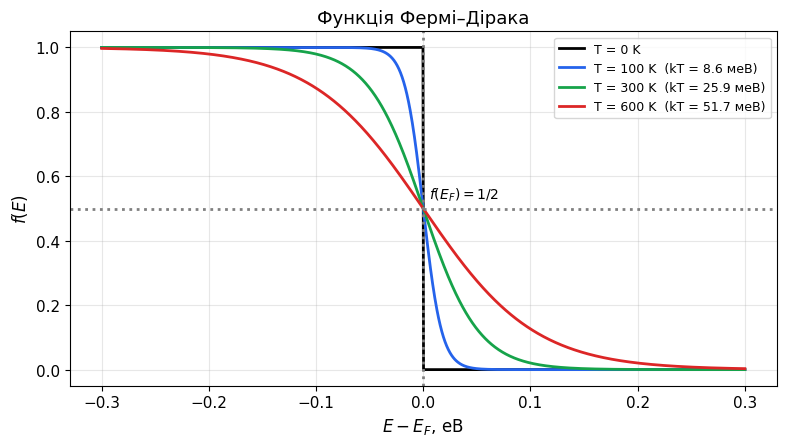

In [6]:
# Функція Фермі–Дірака при різних температурах
dE = np.linspace(-0.3, 0.3, 1200)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(dE, (dE < 0).astype(float), 'k', lw=2, label='T = 0 K')
for T, c in [(100, '#2563eb'), (300, '#16a34a'), (600, '#dc2626')]:
    ax.plot(dE, 1/(1 + np.exp(dE/(kB_eV*T))), color=c, label=f'T = {T} K  (kT = {kB_eV*T*1e3:.1f} меВ)')
ax.axvline(0, color='gray', ls=':'); ax.axhline(0.5, color='gray', ls=':')
ax.text(0.005, 0.53, '$f(E_F) = 1/2$', fontsize=10)
ax.set_xlabel('$E - E_F$, еВ'); ax.set_ylabel('$f(E)$')
ax.set_title('Функція Фермі–Дірака'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 🔬 Інтерактивно: положення рівня Фермі та розподіл носіїв у зонах <a class="anchor" id="fermi-interactive"></a>

Пересувайте рівень Фермі в забороненій зоні кремнію. Ліворуч — зонна діаграма, посередині — $f(E)$, праворуч — розподіл електронів $n(E) = g_c(E) f(E)$ і дірок $p(E) = g_v(E)[1 - f(E)]$. Обидві криві побудовано **в одному масштабі**, тому площі під ними пропорційні концентраціям: коли $E_F$ наближається до $E_c$, дірок стає настільки мало, що їхня крива зникає.

In [7]:
def fermi_explorer(EF=0.56, T=300):
    kT = kB_eV*T; Eg = Eg_T('Si', T)
    E = np.linspace(-0.45, Eg + 0.45, 3000)
    f = 1/(1 + np.exp(np.clip((E - EF)/kT, -700, 700)))
    Nc = MATERIALS['Si']['Nc']*(T/300)**1.5; Nv = MATERIALS['Si']['Nv']*(T/300)**1.5
    gc = Nc*np.sqrt(np.clip(E - Eg, 0, None)); gv = Nv*np.sqrt(np.clip(-E, 0, None))   # g ∝ (m*)^3/2 ∝ N_c,v
    nE, pE = gc*f, gv*(1 - f)
    n0 = Nc*np.exp(-(Eg - EF)/kT); p0 = Nv*np.exp(-EF/kT)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
    ax = axes[0]
    ax.axhline(Eg, color='k', lw=2.5); ax.axhline(0, color='k', lw=2.5)
    ax.fill_between([0, 1], Eg, Eg + 0.45, color='#fee2e2'); ax.fill_between([0, 1], -0.45, 0, color='#bfdbfe')
    ax.axhline(EF, color='r', ls='--', lw=1.8); ax.text(0.02, EF + 0.03, '$E_F$', color='r')
    ax.text(0.02, Eg + 0.03, '$E_c$'); ax.text(0.02, 0.03, '$E_v$')
    ax.set_xticks([]); ax.set_ylabel('E, еВ (від $E_v$)'); ax.set_title('Зонна діаграма Si'); ax.grid(False)
    axes[1].plot(f, E, color='#16a34a'); axes[1].axhline(EF, color='r', ls='--', lw=1)
    axes[1].set_xlabel('$f(E)$'); axes[1].set_title('Фермі–Дірак')
    scale = max(nE.max(), pE.max())
    axes[2].fill_betweenx(E, 0, nE/scale, color='#2563eb', alpha=0.6, label='$n(E)$ — електрони')
    axes[2].fill_betweenx(E, 0, pE/scale, color='#dc2626', alpha=0.6, label='$p(E)$ — дірки')
    axes[2].axhline(EF, color='r', ls='--', lw=1); axes[2].axhline(Eg, color='k', lw=0.8); axes[2].axhline(0, color='k', lw=0.8)
    axes[2].set_xlim(0, 1.05); axes[2].set_xlabel('відн. од. (спільний масштаб)'); axes[2].legend(fontsize=8, loc='center right')
    axes[2].set_title('Розподіл носіїв у зонах')
    axes[0].set_ylim(-0.45, Eg + 0.45)
    plt.tight_layout(); plt.show()
    print(f'n0 = {n0:.2e} см^-3,  p0 = {p0:.2e} см^-3,  n0·p0 = {n0*p0:.2e} = n_i^2 = {ni_T("Si", T)**2:.2e}')
    typ = 'n-тип' if n0 > 10*p0 else ('p-тип' if p0 > 10*n0 else 'близько до власного')
    print(f'n0/p0 = {n0/p0:.1e}  →  {typ}')

interact(fermi_explorer,
         EF=widgets.FloatSlider(min=0.10, max=1.02, step=0.01, value=0.56, description='$E_F$, еВ',
                                continuous_update=False),
         T=widgets.IntSlider(min=200, max=600, step=25, value=300, description='T, К', continuous_update=False));

interactive(children=(FloatSlider(value=0.56, continuous_update=False, description='$E_F$, еВ', max=1.02, min=…

---
### ✅ Питання для самоперевірки: Зонна теорія та носії заряду

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому провідність металу з ростом температури зменшується, а напівпровідника — зростає?</summary>

> **Відповідь:** У металі кількість вільних електронів від температури майже не залежить, а розсіювання на фононах зростає — рухливість і провідність падають. У напівпровіднику кількість носіїв зростає експоненційно ($\propto e^{-E_g/2kT}$), і цей ефект сильніший за зменшення рухливості.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чи може концентрація неосновних носіїв у легованому напівпровіднику перевищити $n_i$?</summary>

> **Відповідь:** У рівновазі — ні: $p_0 = n_i^2/N_d < n_i$, оскільки $N_d > n_i$. Перевищення можливе лише в нерівноважному стані (інжекція, освітлення).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому енергія іонізації донора (≈0,045 еВ) набагато менша за $E_g$ кремнію (1,12 еВ)?</summary>

> **Відповідь:** П'ятий електрон донора рухається в кулонівському полі іона, ослабленому діелектричною проникністю кремнію ($\varepsilon_r \approx 11{,}7$) і з ефективною масою $m^* < m_0$. За воднеподібною моделлю енергія зв'язку $13{,}6\text{ еВ}\cdot(m^*/m_0)/\varepsilon_r^2$ — сотих часток еВ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Де лежить рівень Фермі в напівпровіднику n-типу і чому?</summary>

> **Відповідь:** Вище середини забороненої зони, ближче до $E_c$: $E_c - E_F = kT\ln(N_c/N_d)$. Що сильніше легування, то ближче $E_F$ до $E_c$ (при $N_d \to N_c$ напівпровідник стає виродженим).

</details>

---

# Температурна залежність концентрації носіїв <a class="anchor" id="n-vs-T"></a>

Концентрацію носіїв у легованому напівпровіднику знаходять з **умови електронейтральності**

$$n + N_a^- = p + N_d^+, \qquad N_d^+ = \frac{N_d}{1 + 2\exp\left(\dfrac{E_F - E_d}{kT}\right)},$$

з якої чисельно визначають $E_F$, а потім $n$ і $p$. На залежності $n(T)$ для напівпровідника n-типу виділяють три області:

1. **Виморожування** (низькі $T$, для Si нижче ≈100 К) — донори іонізовані частково, $n < N_d$ і швидко зростає з $T$;
2. **Домішкова (область виснаження домішок)** — всі донори іонізовані, $n \approx N_d = \text{const}$; саме тут працюють напівпровідникові прилади;
3. **Власна провідність** (високі $T$) — $n_i$ перевищує $N_d$, $n \approx p \approx n_i$, прилад втрачає керованість. Для Si з $N_d \sim 10^{15}$ см⁻³ це вище ≈ 500 К, для Ge — вже вище ≈ 350 К. Тому робоча температура кремнієвих приладів — до 125–150 °C, германієвих — до 70–85 °C.

### 🔬 Інтерактивно: три області n(T) та ρ(T) <a class="anchor" id="nT-interactive"></a>

Розв'язується рівняння електронейтральності з неповною іонізацією донорів ($E_c - E_d$ = 0,045 еВ, фосфор) і температурною залежністю $E_g(T)$, $N_{c,v}(T)$. Праворуч — питомий опір $\rho = 1/q(n\mu_n + p\mu_p)$ з рухливістю, яка визначається розсіюванням на фононах ($\mu_L \propto T^{-2{,}4}$) та на іонах домішки ($\mu_I \propto T^{3/2}$): $1/\mu = 1/\mu_L + 1/\mu_I$ (правило Маттіссена).

In [8]:
from scipy.optimize import brentq

def carriers(T, Nd, m='Si', dEd=0.045):
    """Рівноважні n, p, EF (від Ev) з електронейтральності n + 0 = p + Nd+"""
    kT = kB_eV*T; Eg = Eg_T(m, T)
    Nc = MATERIALS[m]['Nc']*(T/300)**1.5; Nv = MATERIALS[m]['Nv']*(T/300)**1.5
    def charge(EF):
        n = Nc*np.exp(-(Eg - EF)/kT); p = Nv*np.exp(-EF/kT)
        Ndp = Nd/(1 + 2*np.exp((EF - (Eg - dEd))/kT))
        return p + Ndp - n
    EF = brentq(charge, -0.3, Eg + 0.3, xtol=1e-9)
    return Nc*np.exp(-(Eg - EF)/kT), Nv*np.exp(-EF/kT), EF, Eg

def n_of_T(Nd_exp=15.0, material='Si'):
    Nd = 10**Nd_exp
    T = np.linspace(25, 800, 500)
    res = np.array([carriers(t, Nd, material) for t in T])
    n, p, EF, Eg = res.T
    # рухливість за правилом Маттіссена: розсіювання на фононах (∝ T^-2,4) + на іонах домішки (∝ T^1,5)
    if material == 'Si':
        muL_n, muL_p, aL = 1414.0, 470.5, (-2.4, -2.2)
        mu300_n = 68.5 + (1414 - 68.5)/(1 + (Nd/9.2e16)**0.711)
        mu300_p = 44.9 + (470.5 - 44.9)/(1 + (Nd/2.23e17)**0.719)
    else:
        muL_n, muL_p, aL = 3900.0, 1900.0, (-1.66, -2.33)
        mu300_n, mu300_p = 3900.0/(1 + Nd/1e17), 1900.0/(1 + Nd/1e17)
    muI_n = 1/(1/mu300_n - 1/muL_n + 1e-12); muI_p = 1/(1/mu300_p - 1/muL_p + 1e-12)
    mun = 1/(1/(muL_n*(T/300)**aL[0]) + 1/(muI_n*(T/300)**1.5))
    mup = 1/(1/(muL_p*(T/300)**aL[1]) + 1/(muI_p*(T/300)**1.5))
    rho = 1/(q*(n*mun + p*mup))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    ax = axes[0]
    ax.semilogy(T, n, color='#2563eb', label='$n$ (електрони)')
    ax.semilogy(T, p, color='#dc2626', label='$p$ (дірки)')
    ax.semilogy(T, [ni_T(material, t) for t in T], 'k:', label='$n_i(T)$')
    ax.axhline(Nd, color='gray', ls='--', lw=1); ax.text(30, Nd*1.4, '$N_d$', color='gray')
    i_fr = np.argmax(n > 0.9*Nd); i_in = np.argmax(ni_T(material, T) > Nd)
    ax.axvspan(T[0], T[i_fr], color='#bfdbfe', alpha=0.4)
    if i_in > 0: ax.axvspan(T[i_in], T[-1], color='#fecaca', alpha=0.4)
    ax.text(T[i_fr]/2 + 10, Nd*1e-3, 'виморожу-\nвання', ha='center', fontsize=8.5)
    ax.text((T[i_fr] + (T[i_in] if i_in > 0 else T[-1]))/2, Nd*1e-3, 'домішкова\nобласть', ha='center', fontsize=8.5)
    if i_in > 0: ax.text((T[i_in] + T[-1])/2, Nd*1e-3, 'власна\nпровідність', ha='center', fontsize=8.5)
    ax.set_ylim(Nd*1e-6, max(n.max(), Nd)*20); ax.set_xlabel('T, К'); ax.set_ylabel('концентрація, см$^{-3}$')
    ax.set_title(f'{material}: $N_d$ = {Nd:.0e} см$^{{-3}}$'); ax.legend(fontsize=8, loc='lower right')
    ax = axes[1]
    Ei = Eg/2 + kB_eV*T/2*np.log(MATERIALS[material]['Nv']/MATERIALS[material]['Nc'])
    ax.plot(T, Eg, 'k', label='$E_c$'); ax.plot(T, 0*T, 'k', label='$E_v$')
    ax.plot(T, Eg - 0.045, color='#2563eb', ls='-.', lw=1, label='$E_d$')
    ax.plot(T, Ei, ':', color='gray', label='$E_i$'); ax.plot(T, EF, 'r--', label='$E_F$')
    ax.set_xlabel('T, К'); ax.set_ylabel('E, еВ (від $E_v$)'); ax.set_title('Положення рівня Фермі'); ax.legend(fontsize=8)
    ax = axes[2]
    ax.semilogy(T, rho, color='#7c3aed'); ax.set_xlabel('T, К'); ax.set_ylabel(r'$\rho$, Ом·см')
    ax.set_title('Питомий опір')
    plt.tight_layout(); plt.show()
    k300 = np.argmin(abs(T - 300))
    print(f'T = 300 K: n = {n[k300]:.3e}, p = {p[k300]:.3e} см^-3, Ec - EF = {Eg[k300]-EF[k300]:.3f} еВ, ρ = {rho[k300]:.3g} Ом·см')
    if i_in > 0: print(f'Власна провідність починає переважати при T ≈ {T[i_in]:.0f} K ({T[i_in]-273:.0f} °C)')

interact(n_of_T,
         Nd_exp=widgets.FloatSlider(min=13, max=18, step=0.5, value=15, description='lg $N_d$',
                                    continuous_update=False),
         material=widgets.ToggleButtons(options=['Si', 'Ge'], value='Si', description='Матеріал'));

interactive(children=(FloatSlider(value=15.0, continuous_update=False, description='lg $N_d$', max=18.0, min=1…

### ⚙️ PySpice: зворотний струм діода як «термометр» n_i² <a class="anchor" id="spice-is-T"></a>

Зворотний струм насичення p-n переходу пропорційний $n_i^2 \propto T^3 \exp(-E_g/kT)$ (Лекція 3). Саме так його масштабує SPICE-модель діода: $I_S(T) = I_S(T_0)\,(T/T_0)^{XTI/N}\exp\!\left[\dfrac{E_g}{Nk}\left(\dfrac{1}{T_0}-\dfrac{1}{T}\right)\right]$ з $XTI = 3$, $N = 1$. Змоделюємо в ngspice струм діода при зворотній напрузі 1 В для «германієвого», «кремнієвого» та «арсенід-галієвого» переходів (параметр `EG`) і порівняємо з теоретичним відношенням $n_i^2(T)/n_i^2(300\ \text{К})$.

> Для збіжності розрахунку ngspice вмикає паралельно кожному p-n переходу малу провідність `GMIN` = 10⁻¹² См. При зворотній напрузі 1 В вона додає 1 пА «витоку», що більший за тепловий струм холодного кремнієвого переходу. Тому в цьому досліді `GMIN` вимкнено.

In [9]:
def reverse_current_vs_T(T_list):
    out = {}
    for name, Eg in [('Ge', 0.67), ('Si', 1.11), ('GaAs', 1.42)]:
        I = []
        for T in T_list:
            c = Circuit('Reverse-biased diode')
            c.model('DX', 'D', IS=1e-12, N=1, EG=Eg, XTI=3)
            c.V('r', 'k', c.gnd, 1.0)                  # +1 В на катод — зворотне зміщення
            c.D('1', c.gnd, 'k', model='DX')
            sim = c.simulator(temperature=T - 273.15, nominal_temperature=26.85)
            sim.options(gmin=1e-30)   # прибираємо допоміжну провідність GMIN (1e-12 См), яку ngspice ставить паралельно переходу
            I.append(-float(sim.operating_point().branches['vr'][0]))
        out[name] = (Eg, np.array(I))
    return out

def plot_rev(Tmax=423):
    T_list = np.arange(220, Tmax + 1, 10.0)   # сітка містить 300 К
    data = reverse_current_vs_T(T_list)
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for name, (Eg, I) in data.items():
        i0 = np.argmin(abs(T_list - 300))
        theory = (T_list/300)**3*np.exp(-Eg/kB_eV*(1/T_list - 1/300))
        ax.semilogy(T_list - 273, I/I[i0], 'o', color=MATERIALS[name]['color'], ms=5, label=f'ngspice, EG = {Eg} еВ ({name})')
        ax.semilogy(T_list - 273, theory, '-', color=MATERIALS[name]['color'], lw=1.3)
    ax.set_xlabel('Температура, °C'); ax.set_ylabel('$I_{зв}(T)\\,/\\,I_{зв}(300\\,К)$')
    ax.set_title('Зворотний струм переходу: ngspice (точки) і $n_i^2(T)$ (лінії)')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()
    Eg = 1.11
    print(f'Si: зростання струму від 25 до 35 °C — у {np.exp(-Eg/kB_eV*(1/308.15-1/298.15))*(308.15/298.15)**3:.2f} раза'
          ' (правило «подвоюється кожні ≈10 °C»)')

interact(plot_rev, Tmax=widgets.IntSlider(min=323, max=473, step=25, value=423, description='$T_{max}$, К',
                                          continuous_update=False));

interactive(children=(IntSlider(value=423, continuous_update=False, description='$T_{max}$, К', max=473, min=3…

---
### ⚡ Практичне застосування: Чому кремній витіснив германій

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перші транзистори (1947–1955) були германієвими: Ge легше очищувати. Але через вузьку заборонену зону ($E_g = 0{,}66$ еВ) власна концентрація Ge при 300 К в ≈2000 разів більша, ніж у Si, а зворотні струми — на три порядки більші й ще швидше ростуть із температурою. Германієві прилади втрачали працездатність уже при 70–80 °C. Кремній ($E_g = 1{,}12$ еВ) працює до 150 °C, а головне — має стабільний власний оксид $SiO_2$, на якому побудована планарна технологія і МДН-транзистори. Для ще вищих температур і напруг застосовують широкозонні SiC і GaN.

</div>

---

# Рух носіїв: дрейф, дифузія, рухливість <a class="anchor" id="transport"></a>

**Дрейф.** В електричному полі $\mathcal{E}$ носії, багаторазово розсіюючись на фононах і домішках, набувають середньої швидкості $v_{др} = \mu \mathcal{E}$, де $\mu$ — **рухливість** (см²/(В·с)). Густина дрейфового струму та питома провідність:

$$j_{др} = q(n\mu_n + p\mu_p)\,\mathcal{E} = \sigma \mathcal{E}, \qquad \rho = \frac{1}{\sigma} = \frac{1}{q(n\mu_n + p\mu_p)}.$$

Для чистого Si при 300 К $\mu_n \approx 1400$, $\mu_p \approx 470$ см²/(В·с) — електрони рухливіші, тому n-p-n транзистори і n-канальні МДН-транзистори швидші за свої p-аналоги. З ростом легування рухливість зменшується через розсіювання на іонах домішок. У сильних полях ($\mathcal{E} > 10^4$ В/см) швидкість **насичується** на рівні $v_{sat} \approx 10^7$ см/с.

**Дифузія.** Якщо концентрація носіїв неоднорідна, хаотичний тепловий рух створює потік з області більшої концентрації в область меншої:

$$j_{n,диф} = qD_n\frac{dn}{dx}, \qquad j_{p,диф} = -qD_p\frac{dp}{dx}, \qquad \frac{D}{\mu} = \frac{kT}{q} = \varphi_T \;\;(\text{співвідношення Ейнштейна}).$$

Повний струм — сума дрейфової і дифузійної складових для обох типів носіїв. У p-n переході (Лекція 2) саме баланс дрейфу і дифузії визначає рівноважний стан.

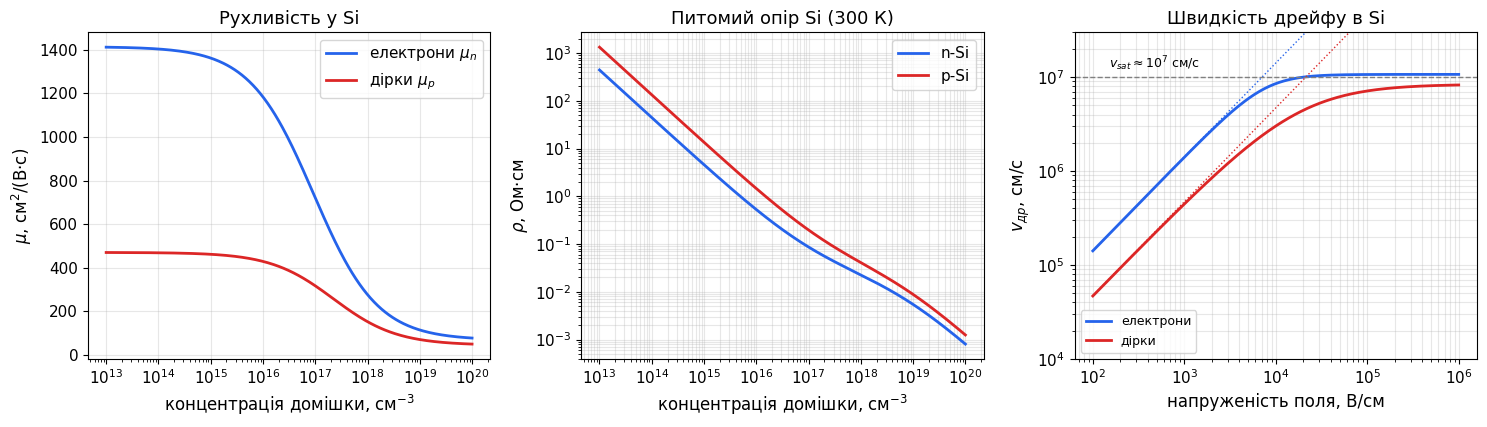

In [10]:
# Рухливість (модель Caughey–Thomas), питомий опір (криві Ірвіна) і насичення швидкості дрейфу, Si, 300 К
N = np.logspace(13, 20, 300)
mu_n = 68.5 + (1414 - 68.5)/(1 + (N/9.2e16)**0.711)
mu_p = 44.9 + (470.5 - 44.9)/(1 + (N/2.23e17)**0.719)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].semilogx(N, mu_n, color='#2563eb', label='електрони $\\mu_n$')
axes[0].semilogx(N, mu_p, color='#dc2626', label='дірки $\\mu_p$')
axes[0].set_xlabel('концентрація домішки, см$^{-3}$'); axes[0].set_ylabel('$\\mu$, см$^2$/(В·с)')
axes[0].set_title('Рухливість у Si'); axes[0].legend()
axes[1].loglog(N, 1/(q*N*mu_n), color='#2563eb', label='n-Si')
axes[1].loglog(N, 1/(q*N*mu_p), color='#dc2626', label='p-Si')
axes[1].set_xlabel('концентрація домішки, см$^{-3}$'); axes[1].set_ylabel(r'$\rho$, Ом·см')
axes[1].set_title('Питомий опір Si (300 К)'); axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)
E = np.logspace(2, 6, 300)
for mu0, vs, beta, lab, c in [(1414, 1.07e7, 2.0, 'електрони', '#2563eb'), (470.5, 0.84e7, 1.0, 'дірки', '#dc2626')]:
    v = mu0*E/(1 + (mu0*E/vs)**beta)**(1/beta)
    axes[2].loglog(E, v, color=c, label=lab)
    axes[2].loglog(E, mu0*E, ':', color=c, lw=1)
axes[2].axhline(1e7, color='gray', ls='--', lw=1); axes[2].text(150, 1.25e7, '$v_{sat} \\approx 10^7$ см/с', fontsize=9)
axes[2].set_ylim(1e4, 3e7); axes[2].set_xlabel('напруженість поля, В/см'); axes[2].set_ylabel('$v_{др}$, см/с')
axes[2].set_title('Швидкість дрейфу в Si'); axes[2].legend(fontsize=9); axes[2].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Дірка — не «позитрон» і не частинка, що рухається «проти» електрона в тій самій зоні провідності. Дірка — це колективний опис руху **електронів валентної зони**: коли електрон перескакує в сусідній вільний зв'язок, вільне місце зсувається в протилежний бік. Тому рухливість дірок ($\mu_p$) інша, ніж у вільних електронів ($\mu_n$), і в кремнії приблизно втричі менша.

</div>

---

# Генерація та рекомбінація. Час життя і дифузійна довжина <a class="anchor" id="recombination"></a>

Якщо рівновагу порушено (світло, інжекція через p-n перехід), з'являються **надлишкові** носії $\Delta n = \Delta p$. Після зняття збудження вони рекомбінують, і надлишок спадає експоненційно:

$$\Delta p(t) = \Delta p(0)\, e^{-t/\tau_p},$$

де $\tau_p$ — **час життя неосновних носіїв** (у Si від наносекунд до мілісекунд залежно від чистоти кристала). У кремнії — **непрямозонному** напівпровіднику — рекомбінація відбувається переважно через **пастки** (рівні дефектів і домішок золота, платини поблизу середини $E_g$; механізм Шоклі–Ріда–Холла), тому Si майже не випромінює світла. У **прямозонних** GaAs, GaN рекомбінація «зона–зона» з випромінюванням фотона домінує — на цьому працюють світлодіоди (Лекція 12).

Якщо надлишкові неосновні носії безперервно вводяться через площину $x = 0$ (так працює емітер діода й транзистора), вони дифундують углиб і одночасно рекомбінують; стаціонарний профіль

$$\Delta p(x) = \Delta p(0)\,e^{-x/L_p}, \qquad L_p = \sqrt{D_p \tau_p}$$

спадає на **дифузійній довжині** $L_p$ — типово десятки–сотні мкм. Співвідношення товщини бази транзистора й $L$ визначає його підсилення (Лекція 5).

In [11]:
def diffusion_profile(tau_us=1.0, mu=450):
    D = mu*phi_T(300)                          # см^2/с, співвідношення Ейнштейна
    L = np.sqrt(D*tau_us*1e-6)*1e4             # мкм
    x = np.linspace(0, 400, 400); t = np.linspace(0, 5*tau_us, 400)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].plot(t, np.exp(-t/tau_us), color='#7c3aed')
    axes[0].axvline(tau_us, color='gray', ls=':'); axes[0].axhline(np.exp(-1), color='gray', ls=':')
    axes[0].text(tau_us*1.03, 0.9, r'$\tau$', fontsize=12)
    axes[0].set_xlabel('t, мкс'); axes[0].set_ylabel(r'$\Delta p(t)/\Delta p(0)$'); axes[0].set_title('Спад після вимкнення збудження')
    axes[1].plot(x, np.exp(-x/L), color='#dc2626')
    axes[1].axvline(L, color='gray', ls=':'); axes[1].axhline(np.exp(-1), color='gray', ls=':')
    axes[1].text(L*1.03, 0.9, '$L_p$', fontsize=12)
    axes[1].set_xlabel('x, мкм'); axes[1].set_ylabel(r'$\Delta p(x)/\Delta p(0)$'); axes[1].set_title('Стаціонарна дифузія з рекомбінацією')
    plt.tight_layout(); plt.show()
    print(f'D_p = {D:.1f} см²/с,  L_p = √(D·τ) = {L:.1f} мкм')

interact(diffusion_profile,
         tau_us=widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.1, description=r'$\tau$, мкс',
                                       continuous_update=False),
         mu=widgets.IntSlider(min=100, max=1400, step=50, value=450, description=r'$\mu$, см²/В·с',
                              continuous_update=False));

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='$\\tau$, мкс', max=2.0, …

---
### ✅ Питання для самоперевірки: Перенесення та рекомбінація носіїв

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що спільного між дрейфовим і дифузійним струмами і чим вони відрізняються?</summary>

> **Відповідь:** Обидва — впорядкований рух носіїв. Дрейф викликаний електричним полем і пропорційний концентрації носіїв; дифузія викликана градієнтом концентрації і може існувати без поля. Їх пов'язує співвідношення Ейнштейна $D = \mu kT/q$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому легування зменшує рухливість, але все одно зменшує питомий опір?</summary>

> **Відповідь:** Іони домішок розсіюють носії, тому $\mu$ спадає (приблизно в 1,2 раза при $N=10^{16}$ см⁻³ і в 5–10 разів при $10^{18}$–$10^{19}$), але концентрація носіїв зростає лінійно з $N$ — на багато порядків, тому $\rho = 1/(qN\mu)$ зменшується.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому кремній погано випромінює світло, а GaAs — добре?</summary>

> **Відповідь:** Si — непрямозонний: мінімум зони провідності і максимум валентної зони відповідають різним хвильовим векторам, тому для випромінювальної рекомбінації потрібен ще фонон; переважає безвипромінювальна рекомбінація через пастки. GaAs — прямозонний, рекомбінація зона–зона з випромінюванням фотона дуже ймовірна.

</details>

---
### 📝 Задачі для самостійного розв'язання: Фізичні основи напівпровідників


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Кремній легований фосфором, $N_d = 10^{16}$ см⁻³, $T = 300$ К ($n_i = 9{,}65\cdot10^9$ см⁻³, $N_c = 2{,}86\cdot10^{19}$ см⁻³). Знайдіть $n_0$, $p_0$, положення рівня Фермі відносно $E_c$ і відносно $E_i$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Усі донори іонізовані: $n_0 \approx N_d = 10^{16}$ см⁻³; $p_0 = n_i^2/N_d = 9312$ см⁻³ $\approx 9{,}3\cdot10^3$ см⁻³. $E_c - E_F = kT\ln(N_c/N_d) = 0{,}02585\cdot\ln(2860) = 0{,}206$ еВ; $E_F - E_i = kT\ln(N_d/n_i) = 0{,}358$ еВ.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Обчисліть питомий опір кремнію з попередньої задачі, якщо $\mu_n = 1184$ см²/(В·с).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\rho = 1/(q N_d \mu_n) = 1/(1{,}602\cdot10^{-19}\cdot10^{16}\cdot1184) = 0{,}527$ Ом·см (внеском дірок можна знехтувати).

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** У скільки разів зростає власна концентрація носіїв у кремнії при нагріванні від 300 до 400 К? Вважайте $E_g = 1{,}12$ еВ сталою.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\dfrac{n_i(400)}{n_i(300)} = \left(\dfrac{400}{300}\right)^{3/2}\exp\left[-\dfrac{E_g}{2k}\left(\dfrac{1}{400}-\dfrac{1}{300}\right)\right] = 1{,}54\cdot e^{5{,}42} \approx 346$ разів.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Електрони в p-базі транзистора мають рухливість $\mu_n = 1350$ см²/(В·с) і час життя $\tau_n = 1$ мкс, $T = 300$ К. Знайдіть коефіцієнт дифузії та дифузійну довжину.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $D_n = \mu_n kT/q = 1350\cdot0{,}02585 = 34{,}9$ см²/с; $L_n = \sqrt{D_n\tau_n} = \sqrt{34{,}9\cdot10^{-6}} \approx 5{,}9\cdot10^{-3}$ см $\approx 59$ мкм.

</details>

---

## 📌 Підсумок лекції 1: Фізичні основи напівпровідників <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула | Si, 300 К |
|---|---|---|
| Ширина забороненої зони | $E_g = E_c - E_v$ | 1,12 еВ |
| Власна концентрація | $n_i = \sqrt{N_cN_v}\,e^{-E_g/2kT}$ | ≈ $10^{10}$ см⁻³ |
| Закон діючих мас | $n_0p_0 = n_i^2$ | — |
| Рівень Фермі (n-тип) | $E_c - E_F = kT\ln(N_c/N_d)$ | 0,21 еВ при $N_d=10^{16}$ |
| Провідність | $\sigma = q(n\mu_n + p\mu_p)$ | $\mu_n \approx 1400$, $\mu_p \approx 470$ см²/(В·с) |
| Співвідношення Ейнштейна | $D = \mu kT/q$ | $kT/q = 25{,}85$ мВ |
| Дифузійна довжина | $L = \sqrt{D\tau}$ | 10–500 мкм |

**Головні висновки.** (1) Провідність напівпровідника визначається кількістю носіїв, яку можна змінювати легуванням на багато порядків. (2) У легованому кристалі основних носіїв набагато більше, ніж неосновних, але саме **неосновні** носії визначають роботу p-n переходу і транзистора. (3) Температура обмежує робочий діапазон приладу зверху (власна провідність) і знизу (виморожування). (4) Струм у напівпровіднику має дві природи — дрейф у полі та дифузію — і в наступній лекції ми побачимо, як їхній баланс формує p-n перехід.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">[Лекція 2. Електронно-дірковий (p-n) перехід](Лекція_02_Електронно-дірковий_перехід.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*